Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.kill(os.getpid(), 9)

Install packages

In [ ]:
!pip install pennylane torch torchvision scikit-learn matplotlib tqdm pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 139.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 114.4 MB/s eta 0:00:00


Set paths and check dataset

In [ ]:
import os
from pathlib import Path

project_root = Path("/content/drive/MyDrive/Project test")
raw_dataset_path = project_root / "DFU" / "Patches"

normal_dir = raw_dataset_path / "Normal(Healthy skin)"
abnormal_dir = raw_dataset_path / "Abnormal(Ulcer)"

print("Project root:", project_root)
print("Raw dataset path:", raw_dataset_path)
print("Normal folder exists:", normal_dir.exists())
print("Abnormal folder exists:", abnormal_dir.exists())

normal_files = [f for f in normal_dir.iterdir() if f.is_file()]
abnormal_files = [f for f in abnormal_dir.iterdir() if f.is_file()]

print("Normal images:", len(normal_files))
print("Abnormal images:", len(abnormal_files))

Project root: /content/drive/MyDrive/Project test
Raw dataset path: /content/drive/MyDrive/Project test/DFU/Patches
Normal folder exists: True
Abnormal folder exists: True
Normal images: 543
Abnormal images: 512


Split dataset into train / val / test automatically

In [ ]:
import random
import shutil

random.seed(42)

processed_root = project_root / "processed_data"
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

classes = {
    "normal": normal_dir,
    "abnormal": abnormal_dir,
}

for split in ["train", "val", "test"]:
    for cls in classes.keys():
        (processed_root / split / cls).mkdir(parents=True, exist_ok=True)

def is_image_file(path):
    return path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"]

for cls_name, cls_path in classes.items():
    files = [f for f in cls_path.iterdir() if f.is_file() and is_image_file(f)]
    random.shuffle(files)

    n = len(files)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    for split_name, split_files in [("train", train_files), ("val", val_files), ("test", test_files)]:
        target_dir = processed_root / split_name / cls_name
        for f in split_files:
            dst = target_dir / f.name
            if not dst.exists():
                shutil.copy2(f, dst)

    print(f"{cls_name}: total={n}, train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

print("Processed dataset created at:", processed_root)

normal: total=543, train=380, val=81, test=82
abnormal: total=512, train=358, val=76, test=78
Processed dataset created at: /content/drive/MyDrive/Project test/processed_data


Create DataLoaders

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

img_size = 224
batch_size = 8

train_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(processed_root / "train", transform=train_transform)
val_dataset = datasets.ImageFolder(processed_root / "val", transform=eval_transform)
test_dataset = datasets.ImageFolder(processed_root / "test", transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Class names:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Class names: ['abnormal', 'normal']
Train size: 738
Val size: 157
Test size: 160


Define the hybrid quantum model

In [ ]:
import numpy as np
import pennylane as qml
import torch.nn as nn
from torchvision import models

def make_qnn_layer(n_qubits=4, n_layers=2):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch")
    def qnode(inputs, weights):
        qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
        qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
        return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

    weight_shapes = {"weights": (n_layers, n_qubits, 3)}
    return qml.qnn.TorchLayer(qnode, weight_shapes)

class HybridQNNModel(nn.Module):
    def __init__(self, pretrained=True, freeze_backbone=True, tune_last_block=False):
        super().__init__()
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = models.resnet18(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        if tune_last_block:
            for p in self.backbone.layer4.parameters():
                p.requires_grad = True

        self.pre_q = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 4),
        )

        self.q_layer = make_qnn_layer(n_qubits=4, n_layers=2)
        self.post_q = nn.Linear(4, 1)

    def forward(self, x):
        x = self.backbone(x)
        x = self.pre_q(x)
        x = torch.tanh(x) * np.pi

        current_device = x.device
        x = x.cpu()
        x = self.q_layer(x)
        x = x.to(current_device)

        x = self.post_q(x)
        return x

Set device, loss, optimizer

In [ ]:
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = HybridQNNModel(
    pretrained=True,
    freeze_backbone=True,
    tune_last_block=False
).to(device)

class_counts = [0, 0]
for _, label in train_dataset.samples:
    class_counts[label] += 1

print("Train class counts:", class_counts)

neg_count = class_counts[0]
pos_count = class_counts[1] if class_counts[1] > 0 else 1
pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.3MB/s]


Train class counts: [358, 380]


Training and evaluation functions

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from tqdm import tqdm

def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)

    losses = []
    y_true = []
    y_prob = []

    pbar = tqdm(loader, leave=False)
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1).float()

        with torch.set_grad_enabled(train):
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.sigmoid(logits)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        losses.append(loss.item())
        y_true.extend(labels.detach().cpu().numpy().flatten().astype(int).tolist())
        y_prob.extend(probs.detach().cpu().numpy().flatten().tolist())

    y_pred = (np.array(y_prob) >= 0.5).astype(int)
    acc = accuracy_score(y_true, y_pred)
    return float(np.mean(losses)), float(acc)

@torch.no_grad()
def predict(model, loader):
    model.eval()
    y_true = []
    y_prob = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1).float()

        logits = model(images)
        probs = torch.sigmoid(logits)

        y_true.extend(labels.cpu().numpy().flatten().astype(int).tolist())
        y_prob.extend(probs.cpu().numpy().flatten().tolist())

    return np.array(y_true), np.array(y_prob)

def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }
    try:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
    except:
        metrics["roc_auc"] = None
    return metrics

Train the model

use this later ep = 100 er = 50

In [ ]:
import copy

epochs = 100
early_stopping_patience = 50

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_state = None
best_val_loss = float("inf")
best_epoch = -1
patience_counter = 0

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{epochs} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print(f"Early stopping at epoch {epoch}")
        break

if best_state is not None:
    model.load_state_dict(best_state)

print("Best epoch:", best_epoch)
print("Best val loss:", best_val_loss)

Epoch 1/100 | train_loss=0.5897 train_acc=0.7683 | val_loss=0.4384 val_acc=0.9745


Epoch 2/100 | train_loss=0.4551 train_acc=0.9106 | val_loss=0.3752 val_acc=0.9745


Epoch 3/100 | train_loss=0.3774 train_acc=0.9268 | val_loss=0.2913 val_acc=0.9809


Epoch 4/100 | train_loss=0.3353 train_acc=0.9241 | val_loss=0.2658 val_acc=0.9809


Epoch 5/100 | train_loss=0.3030 train_acc=0.9417 | val_loss=0.2661 val_acc=0.9554


...

Epoch 96/100 | train_loss=0.1058 train_acc=0.9634 | val_loss=0.0976 val_acc=0.9682


Epoch 97/100 | train_loss=0.1178 train_acc=0.9607 | val_loss=0.1060 val_acc=0.9618


Epoch 98/100 | train_loss=0.1358 train_acc=0.9472 | val_loss=0.0858 val_acc=0.9745


Epoch 99/100 | train_loss=0.1518 train_acc=0.9566 | val_loss=0.0752 val_acc=0.9809


Epoch 100/100 | train_loss=0.1244 train_acc=0.9634 | val_loss=0.1106 val_acc=0.9618
Best epoch: 60
Best val loss: 0.07189485225826502


Test the model and get results

In [ ]:
y_true, y_prob = predict(model, test_loader)
metrics = compute_metrics(y_true, y_prob)

print("Test metrics:")
for k, v in metrics.items():
    print(f"{k}: {v}")

Test metrics:
accuracy: 0.9875
precision: 0.9761904761904762
recall: 1.0
f1: 0.9879518072289156
roc_auc: 0.9996873045653534


Plot loss and accuracy curves

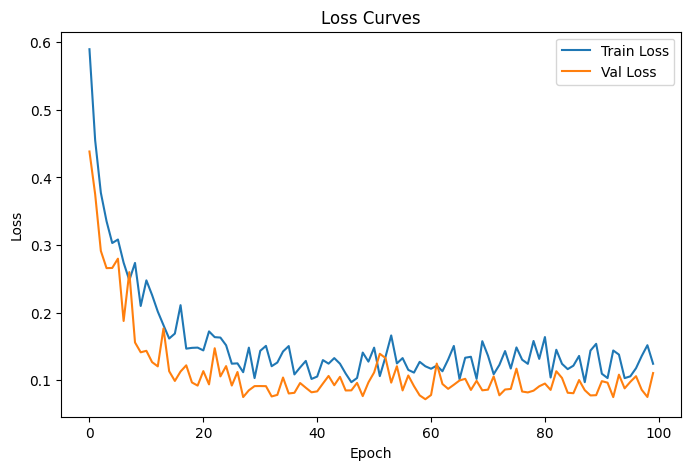

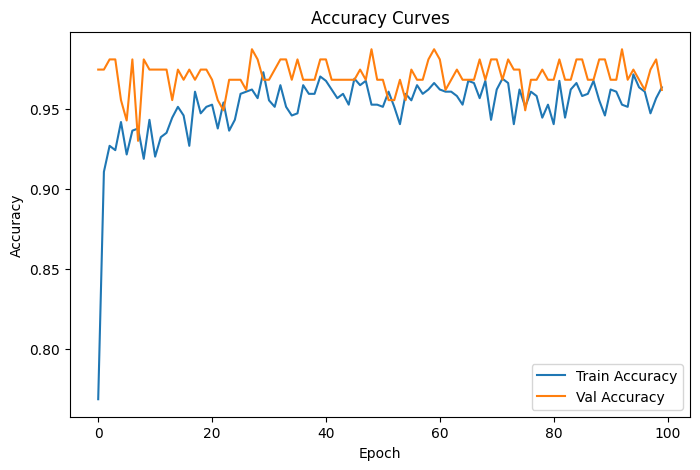

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()
plt.show()

Confusion matrix and ROC curve

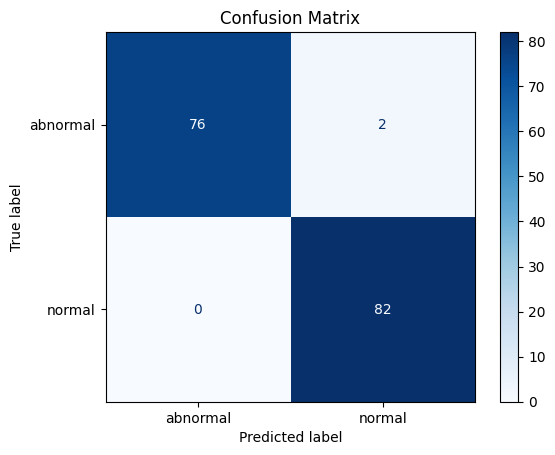

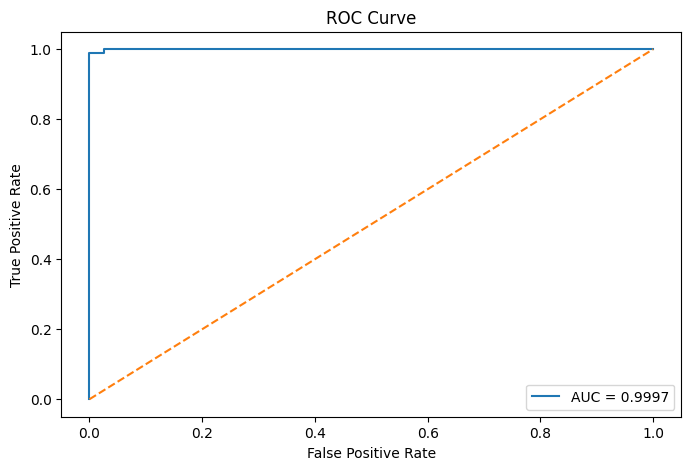

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Save model and results to Google Drive

In [ ]:
import json

results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

model_path = results_dir / "hybrid_qnn_model.pt"
metrics_path = results_dir / "metrics.json"

torch.save({
    "model_state_dict": model.state_dict(),
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "metrics": metrics,
}, model_path)

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved model to:", model_path)
print("Saved metrics to:", metrics_path)

Saved model to: /content/drive/MyDrive/Project test/results/hybrid_qnn_model.pt
Saved metrics to: /content/drive/MyDrive/Project test/results/metrics.json
